# 05a – ML Baseline (SVM / RF / XGBoost)

**Cél:** Hagyományos ML modellek a `features_v14.npz` feature vektoron.

**Kísérlet A:** SVM csak Group B-n (42 dim wrist-normalized) — "kézpóz-only" plafon  
**Kísérlet B:** SVM teljes 56-dim vektoron (B+D+F+G+H)  
**Kísérlet C:** Random Forest + XGBoost teljes vektoron  

**Döntési kapuk:**
- Ha B-kísérlet >80% val acc → fogólap pipeline nem szükséges
- Ha teljes vektor nem javít >2%-ot a B-hez képest → G/H feature-ök nem hasznosak

**FONTOS:** Test set adatot NEM töltünk be – az kizárólag `06_evaluation.ipynb` feladata.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from src.config import CFG, PATHS
from src.features import load_features, feature_names

CHECKPOINT_DIR = PATHS['checkpoint_dir']
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = PATHS['output_dir'] / '05a_baseline_ml'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Modulok betöltve.')

Modulok betöltve.


In [2]:
# Feature betöltés
data = load_features()
X = data['X']           # (297, 56)
y = data['y']           # (297,)
classes = data['classes']
splits = np.array(data['splits'])
fn = feature_names()

train_mask = splits == 'train'
val_mask   = splits == 'val'

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

# Group B index-ek (0:42)
B_cols = list(range(0, 42))

print(f'Train: {len(X_train)}  Val: {len(X_val)}')
print(f'Feature dim: {X.shape[1]}  Classes: {classes}')

Train: 207  Val: 45
Feature dim: 56  Classes: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('No hand')]


## Kísérlet A – SVM csak Group B-n (kézpóz-only plafon)

In [3]:
svm_b = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=CFG['random_seed'])),
])
svm_b.fit(X_train[:, B_cols], y_train)

pred_b_val = svm_b.predict(X_val[:, B_cols])
acc_b = accuracy_score(y_val, pred_b_val)
f1_b  = f1_score(y_val, pred_b_val, average='macro')
print(f'SVM (Group B only, 42 dim)  val_acc={acc_b:.3f}  macro_f1={f1_b:.3f}')

if acc_b > 0.80:
    print('  → >80% acc: fogólap pipeline nem szükséges (kézpóz elegendő)')
else:
    print(f'  → {acc_b:.1%} acc: fogólap feature-ök potenciálisan hasznosak')

SVM (Group B only, 42 dim)  val_acc=0.956  macro_f1=0.953
  → >80% acc: fogólap pipeline nem szükséges (kézpóz elegendő)


## Kísérlet B – SVM teljes vektoron (56 dim)

In [4]:
svm_full = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=CFG['random_seed'])),
])
svm_full.fit(X_train, y_train)

pred_full_val = svm_full.predict(X_val)
acc_full = accuracy_score(y_val, pred_full_val)
f1_full  = f1_score(y_val, pred_full_val, average='macro')
print(f'SVM (56 dim full)  val_acc={acc_full:.3f}  macro_f1={f1_full:.3f}')

delta = acc_full - acc_b
print(f'Delta vs Group B: {delta:+.3f}')
if delta < 0.02:
    print('  → <2% javulás: G/H feature-ök nem hoznak érdemi jelet')
else:
    print('  → ≥2% javulás: fogólap feature-ök hasznosak')

SVM (56 dim full)  val_acc=0.933  macro_f1=0.932
Delta vs Group B: -0.022
  → <2% javulás: G/H feature-ök nem hoznak érdemi jelet


## Kísérlet C – Random Forest + XGBoost

In [5]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                             random_state=CFG['random_seed'], n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, pred_rf)
f1_rf  = f1_score(y_val, pred_rf, average='macro')
print(f'Random Forest (56 dim)     val_acc={acc_rf:.3f}  macro_f1={f1_rf:.3f}')

Random Forest (56 dim)     val_acc=0.956  macro_f1=0.943


In [6]:
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         eval_metric='mlogloss', random_state=CFG['random_seed'],
                         verbosity=0, use_label_encoder=False)
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_val)
    acc_xgb = accuracy_score(y_val, pred_xgb)
    f1_xgb  = f1_score(y_val, pred_xgb, average='macro')
    print(f'XGBoost (56 dim)           val_acc={acc_xgb:.3f}  macro_f1={f1_xgb:.3f}')
    HAS_XGB = True
except ImportError:
    print('XGBoost nem elérhető – kihagyva')
    HAS_XGB = False

XGBoost nem elérhető – kihagyva


## Összefoglaló + legjobb modell mentése

In [7]:
results = [
    ('SVM (Group B, 42d)', acc_b,    f1_b,    svm_b),
    ('SVM (full, 56d)',    acc_full,  f1_full,  svm_full),
    ('RandomForest',       acc_rf,    f1_rf,    rf),
]
if HAS_XGB:
    results.append(('XGBoost', acc_xgb, f1_xgb, xgb))

print('=' * 55)
print(f'{"Modell":<25}  {"Val Acc":>8}  {"Macro F1":>9}')
print('-' * 55)
best_acc, best_model, best_name = 0, None, ''
for name, acc, f1, mdl in results:
    print(f'{name:<25}  {acc:>8.3f}  {f1:>9.3f}')
    if acc > best_acc:
        best_acc, best_model, best_name = acc, mdl, name
print('=' * 55)
print(f'Legjobb: {best_name}  (val_acc={best_acc:.3f})')

Modell                      Val Acc   Macro F1
-------------------------------------------------------
SVM (Group B, 42d)            0.956      0.953
SVM (full, 56d)               0.933      0.932
RandomForest                  0.956      0.943
Legjobb: SVM (Group B, 42d)  (val_acc=0.956)


In [8]:
# Legjobb modell mentése (06_evaluation.ipynb fogja betölteni)
ckpt_path = CHECKPOINT_DIR / 'best_ml_model.pkl'
with open(ckpt_path, 'wb') as f:
    pickle.dump({'model': best_model, 'name': best_name, 'val_acc': best_acc,
                 'classes': classes, 'feature_names': fn}, f)
print(f'Legjobb ML modell mentve: {ckpt_path}')

Legjobb ML modell mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/checkpoints/best_ml_model.pkl


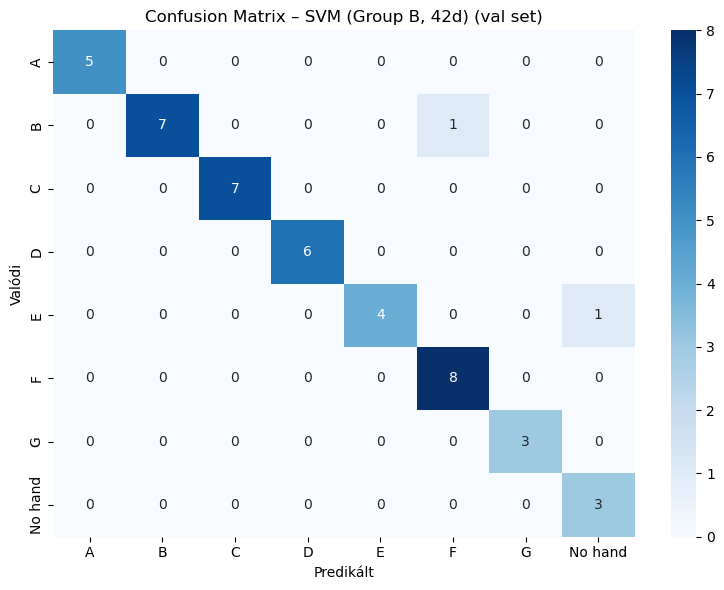

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         5
           B       1.00      0.88      0.93         8
           C       1.00      1.00      1.00         7
           D       1.00      1.00      1.00         6
           E       1.00      0.80      0.89         5
           F       0.89      1.00      0.94         8
           G       1.00      1.00      1.00         3
     No hand       0.75      1.00      0.86         3

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



In [9]:
# Confusion matrix a legjobb modellen
if best_name.startswith('SVM (Group B'):
    pred_best = svm_b.predict(X_val[:, B_cols])
elif best_name.startswith('SVM'):
    pred_best = svm_full.predict(X_val)
elif best_name == 'RandomForest':
    pred_best = rf.predict(X_val)
else:
    pred_best = xgb.predict(X_val)

cm = confusion_matrix(y_val, pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predikált'); ax.set_ylabel('Valódi')
ax.set_title(f'Confusion Matrix – {best_name} (val set)')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_val.png', dpi=120)
plt.show()
print(classification_report(y_val, pred_best, target_names=classes))

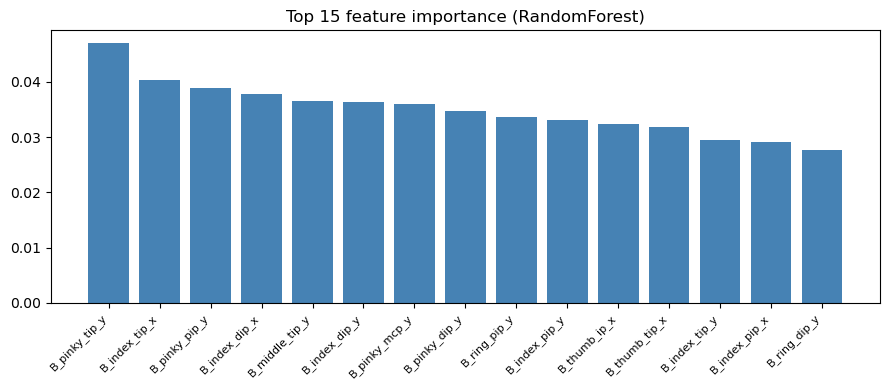

In [10]:
# Feature importance (RF)
fi = rf.feature_importances_
top_n = 15
idx = np.argsort(fi)[::-1][:top_n]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(top_n), fi[idx], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels([fn[i] for i in idx], rotation=45, ha='right', fontsize=8)
ax.set_title('Top 15 feature importance (RandomForest)')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=120)
plt.show()